**FOCUS OF THE EDA**

This notebook creates a combined daily EDA for the public YouTube, Spotify, Netflix, Prime Video, and academic calendar datasets.

The goal is not to test hypotheses yet. The goal is to build a careful daily panel and inspect whether the platform-level patterns make sense before later hypothesis testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Course recitation style: readable grid, colorblind palette, clear labels.
sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")

# Path handling that works from either the repo root or the EDA folder.
if Path("data_github/youtube_public/youtube_activity_public.csv").exists():
    base_dir = Path(".")
    combined_image_dir = Path("EDA/combined_images")
else:
    base_dir = Path("..")
    combined_image_dir = Path("combined_images")

combined_image_dir.mkdir(parents=True, exist_ok=True)

# Public GitHub-facing datasets only.
youtube_path = base_dir / "data_github/youtube_public/youtube_activity_public.csv"
spotify_path = base_dir / "data_github/spotify_public/spotify_streaming_public.csv"
netflix_path = base_dir / "data_github/netflix_public/netflix_viewing_public.csv"
prime_path = base_dir / "data_github/prime_video_public/prime_video_watch_history_public.csv"
calendar_path = base_dir / "data_github/academical_calendar/academicCalendar.jsonl"

In [83]:
# Loading public datasets.
youtube_data = pd.read_csv(youtube_path)
spotify_data = pd.read_csv(spotify_path)
netflix_data = pd.read_csv(netflix_path)
prime_data = pd.read_csv(prime_path)
calendar_data = pd.read_json(calendar_path, lines=True)

print("Dataset shapes:")
print("YouTube:", youtube_data.shape)
print("Spotify:", spotify_data.shape)
print("Netflix:", netflix_data.shape)
print("Prime Video:", prime_data.shape)
print("Academic calendar:", calendar_data.shape)

Dataset shapes:
YouTube: (34317, 16)
Spotify: (178202, 16)
Netflix: (2493, 11)
Prime Video: (719, 17)
Academic calendar: (15, 23)


In [84]:
# Parsing dates.
youtube_data["fine_date"] = pd.to_datetime(youtube_data["fine_date"])
spotify_data["fine_date"] = pd.to_datetime(spotify_data["fine_date"])
netflix_data["fine_date"] = pd.to_datetime(netflix_data["fine_date"])
prime_data["fine_date"] = pd.to_datetime(prime_data["fine_date"])

# YouTube timestamps already include timezone offsets. Parse as UTC, then convert to Istanbul time.
youtube_data["fine_time_start_dt"] = pd.to_datetime(
    youtube_data["fine_time_start"],
    errors="coerce",
    utc=True
).dt.tz_convert("Europe/Istanbul")

# Spotify timestamps are ISO strings, but some have fractional seconds and some do not.
spotify_data["fine_time_start_dt"] = pd.to_datetime(
    spotify_data["fine_time_start"],
    errors="coerce",
    utc=True,
    format="ISO8601"
).dt.tz_convert("Europe/Istanbul")

print("Date ranges:")
print("YouTube:", youtube_data["fine_date"].min(), "to", youtube_data["fine_date"].max())
print("Spotify:", spotify_data["fine_date"].min(), "to", spotify_data["fine_date"].max())
print("Netflix:", netflix_data["fine_date"].min(), "to", netflix_data["fine_date"].max())
print("Prime Video:", prime_data["fine_date"].min(), "to", prime_data["fine_date"].max())

print()
print("Invalid timestamp counts:")
print("YouTube:", youtube_data["fine_time_start_dt"].isna().sum())
print("Spotify:", spotify_data["fine_time_start_dt"].isna().sum())

Date ranges:
YouTube: 2022-04-17 00:00:00 to 2026-03-15 00:00:00
Spotify: 2019-07-27 00:00:00 to 2026-03-14 00:00:00
Netflix: 2020-02-25 00:00:00 to 2026-03-10 00:00:00
Prime Video: 2022-03-30 00:00:00 to 2026-03-19 00:00:00

Invalid timestamp counts:
YouTube: 0
Spotify: 0


In [85]:
# The combined EDA uses the common 4-platform coverage window.
common_start_date = max(
    youtube_data["fine_date"].min(),
    spotify_data["fine_date"].min(),
    netflix_data["fine_date"].min(),
    prime_data["fine_date"].min()
)

common_end_date = min(
    youtube_data["fine_date"].max(),
    spotify_data["fine_date"].max(),
    netflix_data["fine_date"].max(),
    prime_data["fine_date"].max()
)

all_dates = pd.DataFrame({
    "fine_date": pd.date_range(start=common_start_date, end=common_end_date, freq="D")
})

print("Common 4-platform date range:")
print(common_start_date, "to", common_end_date)
print("Number of days:", len(all_dates))

Common 4-platform date range:
2022-04-17 00:00:00 to 2026-03-10 00:00:00
Number of days: 1424


**Academic Calendar Labels**

The academic calendar is used only as a label source. Summer calendar days are labeled as `summer_work_period` because I was working during summer rather than taking summer school.

In [86]:
# Expanding the academic calendar into one row per date.
calendar_rows = []

for _, row in calendar_data.iterrows():
    term_start = pd.to_datetime(row["term_start_date"])
    final_start = pd.to_datetime(row["final_exam_start_date"])
    final_end = pd.to_datetime(row["final_exam_end_date"])

    for date_value in pd.date_range(term_start, final_end, freq="D"):
        if final_start <= date_value <= final_end:
            academic_period = "final_exam"
        else:
            # Add/drop is not a separate focus in this project, so it stays inside ordinary term.
            academic_period = "ordinary_term"

        # Summer is a work period in this project context, not summer-school pressure.
        if row["term"] == "summer":
            analysis_period = "summer_work_period"
        else:
            analysis_period = academic_period

        calendar_rows.append({
            "fine_date": date_value,
            "academic_year": row["academic_year"],
            "term": row["term"],
            "academic_period": academic_period,
            "analysis_period": analysis_period,
            "is_final_exam_period": academic_period == "final_exam",
            "is_ordinary_term_day": academic_period == "ordinary_term"
        })

calendar_daily = pd.DataFrame(calendar_rows).drop_duplicates("fine_date", keep="first")

print("Calendar daily sample:")
print(calendar_daily.head())
print()
print("Calendar labels:")
print(calendar_daily["analysis_period"].value_counts())


Calendar daily sample:
   fine_date academic_year  term academic_period analysis_period  \
0 2021-09-27     2021-2022  fall   ordinary_term   ordinary_term   
1 2021-09-28     2021-2022  fall   ordinary_term   ordinary_term   
2 2021-09-29     2021-2022  fall   ordinary_term   ordinary_term   
3 2021-09-30     2021-2022  fall   ordinary_term   ordinary_term   
4 2021-10-01     2021-2022  fall   ordinary_term   ordinary_term   

   is_final_exam_period  is_ordinary_term_day  
0                 False                  True  
1                 False                  True  
2                 False                  True  
3                 False                  True  
4                 False                  True  

Calendar labels:
analysis_period
ordinary_term         1010
summer_work_period     255
final_exam             119
Name: count, dtype: int64


**Daily Platform Variables**

Each platform is aggregated to the day level before merging. Dates without rows are filled as zero activity for that platform.

In [87]:
# After-9:30 PM flag for timestamped platforms.
youtube_data["minute_of_day"] = youtube_data["fine_time_start_dt"].dt.hour * 60 + youtube_data["fine_time_start_dt"].dt.minute
spotify_data["minute_of_day"] = spotify_data["fine_time_start_dt"].dt.hour * 60 + spotify_data["fine_time_start_dt"].dt.minute

youtube_data["is_after_2130"] = (
    (youtube_data["minute_of_day"] >= (21 * 60 + 30)) |
    (youtube_data["minute_of_day"] < (5 * 60))
)

spotify_data["is_after_2130"] = (
    (spotify_data["minute_of_day"] >= (21 * 60 + 30)) |
    (spotify_data["minute_of_day"] < (5 * 60))
)

print("YouTube after-21:30 rows:")
print(youtube_data["is_after_2130"].value_counts())
print()
print("Spotify after-21:30 rows:")
print(spotify_data["is_after_2130"].value_counts())

YouTube after-21:30 rows:
is_after_2130
False    18803
True     15514
Name: count, dtype: int64

Spotify after-21:30 rows:
is_after_2130
False    117472
True      60730
Name: count, dtype: int64


In [88]:
# YouTube daily variables.
youtube_daily_total = youtube_data.groupby("fine_date").size().reset_index(name="youtube_daily_total_count")
youtube_daily_watched = youtube_data[youtube_data["action"] == "Watched"].groupby("fine_date").size().reset_index(name="youtube_daily_watched_count")
youtube_daily_search = youtube_data[youtube_data["action"] == "Searched for"].groupby("fine_date").size().reset_index(name="youtube_daily_search_count")
youtube_after_2130 = youtube_data[youtube_data["is_after_2130"]].groupby("fine_date").size().reset_index(name="youtube_after_2130_count")
youtube_after_2130_watched = youtube_data[
    youtube_data["is_after_2130"] & (youtube_data["action"] == "Watched")
].groupby("fine_date").size().reset_index(name="youtube_after_2130_watched_count")

youtube_daily = (
    all_dates
    .merge(youtube_daily_total, on="fine_date", how="left")
    .merge(youtube_daily_watched, on="fine_date", how="left")
    .merge(youtube_daily_search, on="fine_date", how="left")
    .merge(youtube_after_2130, on="fine_date", how="left")
    .merge(youtube_after_2130_watched, on="fine_date", how="left")
)

for column in youtube_daily.columns:
    if column != "fine_date":
        youtube_daily[column] = youtube_daily[column].fillna(0).astype(int)

print("YouTube daily sample:")
print(youtube_daily.head())

YouTube daily sample:
   fine_date  youtube_daily_total_count  youtube_daily_watched_count  \
0 2022-04-17                          1                            0   
1 2022-04-18                          0                            0   
2 2022-04-19                          0                            0   
3 2022-04-20                          0                            0   
4 2022-04-21                          0                            0   

   youtube_daily_search_count  youtube_after_2130_count  \
0                           0                         0   
1                           0                         0   
2                           0                         0   
3                           0                         0   
4                           0                         0   

   youtube_after_2130_watched_count  
0                                 0  
1                                 0  
2                                 0  
3                                 0  


In [89]:
# Spotify daily variables.
spotify_daily = (
    spotify_data
    .groupby("fine_date")
    .agg(
        spotify_daily_hours=("hours_played", "sum"),
        spotify_daily_stream_count=("fine_record_id", "count"),
        spotify_daily_unique_tracks=("track_ref_id", "nunique")
    )
    .reset_index()
)

spotify_after_2130 = (
    spotify_data[spotify_data["is_after_2130"]]
    .groupby("fine_date")
    .agg(
        spotify_after_2130_hours=("hours_played", "sum"),
        spotify_after_2130_stream_count=("fine_record_id", "count")
    )
    .reset_index()
)

spotify_daily = (
    all_dates
    .merge(spotify_daily, on="fine_date", how="left")
    .merge(spotify_after_2130, on="fine_date", how="left")
)

spotify_daily["spotify_daily_hours"] = spotify_daily["spotify_daily_hours"].fillna(0)
spotify_daily["spotify_daily_stream_count"] = spotify_daily["spotify_daily_stream_count"].fillna(0).astype(int)
spotify_daily["spotify_daily_unique_tracks"] = spotify_daily["spotify_daily_unique_tracks"].fillna(0).astype(int)
spotify_daily["spotify_after_2130_hours"] = spotify_daily["spotify_after_2130_hours"].fillna(0)
spotify_daily["spotify_after_2130_stream_count"] = spotify_daily["spotify_after_2130_stream_count"].fillna(0).astype(int)

print("Spotify daily sample:")
print(spotify_daily.head())

Spotify daily sample:
   fine_date  spotify_daily_hours  spotify_daily_stream_count  \
0 2022-04-17             1.603053                          70   
1 2022-04-18             0.385654                          11   
2 2022-04-19             0.002694                           7   
3 2022-04-20             0.905688                         135   
4 2022-04-21             0.634982                          64   

   spotify_daily_unique_tracks  spotify_after_2130_hours  \
0                           63                  0.117174   
1                            9                  0.264308   
2                            2                  0.000000   
3                          103                  0.905688   
4                           49                  0.268858   

   spotify_after_2130_stream_count  
0                               25  
1                               10  
2                                1  
3                              135  
4                               28  


In [90]:
# Netflix and Prime Video daily variables.
netflix_daily = netflix_data.groupby("fine_date").size().reset_index(name="netflix_daily_count")
prime_daily = prime_data.groupby("fine_date").size().reset_index(name="prime_video_daily_count")

netflix_daily = all_dates.merge(netflix_daily, on="fine_date", how="left")
prime_daily = all_dates.merge(prime_daily, on="fine_date", how="left")

netflix_daily["netflix_daily_count"] = netflix_daily["netflix_daily_count"].fillna(0).astype(int)
prime_daily["prime_video_daily_count"] = prime_daily["prime_video_daily_count"].fillna(0).astype(int)

print("Netflix daily sample:")
print(netflix_daily.head())
print()
print("Prime Video daily sample:")
print(prime_daily.head())

Netflix daily sample:
   fine_date  netflix_daily_count
0 2022-04-17                    0
1 2022-04-18                    0
2 2022-04-19                    0
3 2022-04-20                    1
4 2022-04-21                    0

Prime Video daily sample:
   fine_date  prime_video_daily_count
0 2022-04-17                        0
1 2022-04-18                        0
2 2022-04-19                        0
3 2022-04-20                        0
4 2022-04-21                        0


**Combined Daily Panel**

This panel is kept inside the notebook for EDA. It is not saved as a new public dataset yet.

`netflix_prime_daily_count` means the Netflix daily viewing count plus the Prime Video daily viewing count for the same date. I use this name because it tells the reader exactly which platforms are being added.

`daily_distinct_entertainment_platform_count` counts how many of the four entertainment platforms had activity on that date: YouTube, Spotify, Netflix, and Prime Video.


In [91]:
# Merging all daily platform tables.
combined_daily = (
    all_dates
    .merge(youtube_daily, on="fine_date", how="left")
    .merge(spotify_daily, on="fine_date", how="left")
    .merge(netflix_daily, on="fine_date", how="left")
    .merge(prime_daily, on="fine_date", how="left")
    .merge(calendar_daily, on="fine_date", how="left")
)

# Fill labels for dates outside the academic calendar.
combined_daily["academic_year"] = combined_daily["academic_year"].fillna("outside_calendar")
combined_daily["term"] = combined_daily["term"].fillna("outside_calendar")
combined_daily["academic_period"] = combined_daily["academic_period"].fillna("outside_calendar")
combined_daily["analysis_period"] = combined_daily["analysis_period"].fillna("outside_calendar")

for column in ["is_final_exam_period", "is_ordinary_term_day"]:
    combined_daily[column] = combined_daily[column].fillna(False).astype(bool)

# Extra cross-platform variables.
combined_daily["netflix_prime_daily_count"] = (
    combined_daily["netflix_daily_count"] + combined_daily["prime_video_daily_count"]
)

combined_daily["youtube_active_day"] = combined_daily["youtube_daily_total_count"] > 0
combined_daily["spotify_active_day"] = combined_daily["spotify_daily_stream_count"] > 0
combined_daily["netflix_active_day"] = combined_daily["netflix_daily_count"] > 0
combined_daily["prime_video_active_day"] = combined_daily["prime_video_daily_count"] > 0
combined_daily["netflix_prime_active_day"] = combined_daily["netflix_prime_daily_count"] > 0

combined_daily["daily_distinct_entertainment_platform_count"] = combined_daily[[
    "youtube_active_day",
    "spotify_active_day",
    "netflix_active_day",
    "prime_video_active_day"
]].sum(axis=1).astype(int)

combined_daily["total_entertainment_event_count"] = (
    combined_daily["youtube_daily_total_count"] +
    combined_daily["spotify_daily_stream_count"] +
    combined_daily["netflix_prime_daily_count"]
)

combined_daily["youtube_after_2130_share"] = (
    combined_daily["youtube_after_2130_count"] /
    combined_daily["youtube_daily_total_count"].replace(0, np.nan)
).fillna(0)

combined_daily["spotify_after_2130_hour_share"] = (
    combined_daily["spotify_after_2130_hours"] /
    combined_daily["spotify_daily_hours"].replace(0, np.nan)
).fillna(0)

print("Combined daily shape:")
print(combined_daily.shape)
print()
print("Combined daily sample:")
print(combined_daily.head())


Combined daily shape:
(1424, 29)

Combined daily sample:
   fine_date  youtube_daily_total_count  youtube_daily_watched_count  \
0 2022-04-17                          1                            0   
1 2022-04-18                          0                            0   
2 2022-04-19                          0                            0   
3 2022-04-20                          0                            0   
4 2022-04-21                          0                            0   

   youtube_daily_search_count  youtube_after_2130_count  \
0                           0                         0   
1                           0                         0   
2                           0                         0   
3                           0                         0   
4                           0                         0   

   youtube_after_2130_watched_count  spotify_daily_hours  \
0                                 0             1.603053   
1                                 0

/var/folders/bg/1f1k786920g5016jzpkv6dxc0000gn/T/ipykernel_3943/3515838891.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_daily[column] = combined_daily[column].fillna(False).astype(bool)
/var/folders/bg/1f1k786920g5016jzpkv6dxc0000gn/T/ipykernel_3943/3515838891.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_daily[column] = combined_daily[column].fillna(False).astype(bool)


In [92]:
# Simple validation checks for the EDA panel.
assert combined_daily["fine_date"].is_unique
assert len(combined_daily) == len(all_dates)
assert combined_daily["fine_date"].min() == common_start_date
assert combined_daily["fine_date"].max() == common_end_date
assert youtube_data["fine_time_start_dt"].isna().sum() == 0
assert spotify_data["fine_time_start_dt"].isna().sum() == 0
assert (combined_daily["netflix_prime_daily_count"] == combined_daily["netflix_daily_count"] + combined_daily["prime_video_daily_count"]).all()
assert combined_daily["daily_distinct_entertainment_platform_count"].between(0, 4).all()

count_columns = [
    "youtube_daily_total_count",
    "youtube_daily_watched_count",
    "youtube_daily_search_count",
    "spotify_daily_stream_count",
    "netflix_daily_count",
    "prime_video_daily_count",
    "netflix_prime_daily_count"
]

assert combined_daily[count_columns].isna().sum().sum() == 0
assert (combined_daily[count_columns] >= 0).all().all()

print("Combined EDA validation checks passed.")
print()
print("Analysis period counts:")
print(combined_daily["analysis_period"].value_counts())

Combined EDA validation checks passed.

Analysis period counts:
analysis_period
ordinary_term         775
outside_calendar      348
summer_work_period    204
final_exam             97
Name: count, dtype: int64


In [93]:
print("Combined daily summary:")
print(combined_daily[[
    "youtube_daily_watched_count",
    "youtube_daily_search_count",
    "spotify_daily_hours",
    "spotify_daily_stream_count",
    "netflix_daily_count",
    "prime_video_daily_count",
    "netflix_prime_daily_count",
    "daily_distinct_entertainment_platform_count"
]].describe())

Combined daily summary:
       youtube_daily_watched_count  youtube_daily_search_count  \
count                  1424.000000                 1424.000000   
mean                     22.302669                    1.484551   
std                      41.117990                    2.464600   
min                       0.000000                    0.000000   
25%                       0.000000                    0.000000   
50%                       3.000000                    0.000000   
75%                      29.000000                    2.000000   
max                     336.000000                   18.000000   

       spotify_daily_hours  spotify_daily_stream_count  netflix_daily_count  \
count          1424.000000                 1424.000000          1424.000000   
mean              1.888959                   94.609551             1.018961   
std               1.564486                   99.489198             3.809823   
min               0.000000                    0.000000           

**Coverage And Sanity Plots**

These plots check whether the platform coverage and activity availability look reasonable before doing any hypothesis testing.

The coverage plot shows the date span of each public dataset. The dashed vertical lines mark the common range used in this notebook, so every platform is inside its available data range.

The active-day plot counts how many days each platform had at least one record. This does not compare intensity; it only checks whether a platform was used on a day.


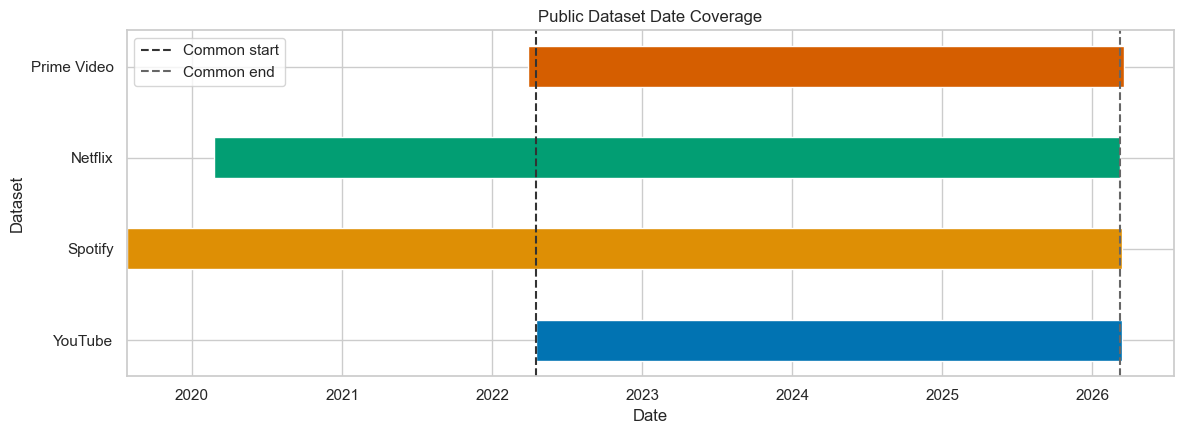

In [94]:
# Dataset date coverage plot.
coverage_data = pd.DataFrame({
    "dataset": ["YouTube", "Spotify", "Netflix", "Prime Video"],
    "start_date": [
        youtube_data["fine_date"].min(),
        spotify_data["fine_date"].min(),
        netflix_data["fine_date"].min(),
        prime_data["fine_date"].min()
    ],
    "end_date": [
        youtube_data["fine_date"].max(),
        spotify_data["fine_date"].max(),
        netflix_data["fine_date"].max(),
        prime_data["fine_date"].max()
    ]
})

fig, ax = plt.subplots(figsize=(12, 4.5))

for row_index, row in coverage_data.iterrows():
    ax.barh(
        row["dataset"],
        (row["end_date"] - row["start_date"]).days,
        left=row["start_date"],
        height=0.45
    )

ax.axvline(common_start_date, color="#333333", linestyle="--", label="Common start")
ax.axvline(common_end_date, color="#666666", linestyle="--", label="Common end")
ax.set_title("Public Dataset Date Coverage")
ax.set_xlabel("Date")
ax.set_ylabel("Dataset")
ax.legend()
plt.tight_layout()

plt.savefig(combined_image_dir / "combined_dataset_date_coverage.png", dpi=300)
plt.show()

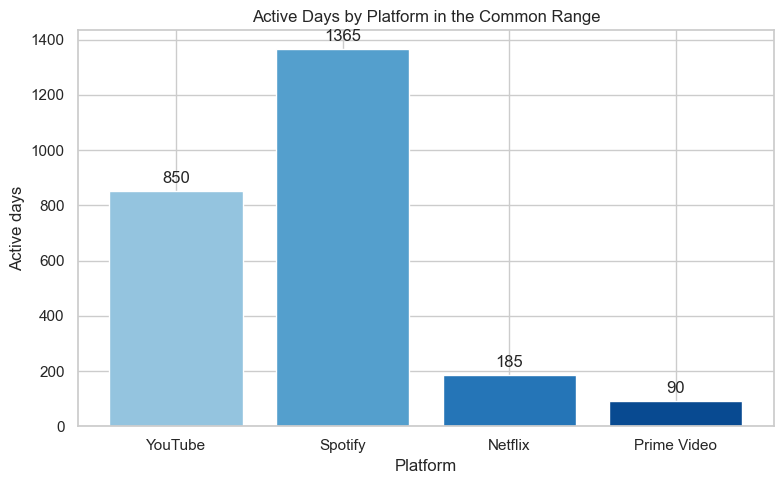

In [95]:
# Active-day summary for each platform in the common range.
active_day_counts = pd.DataFrame({
    "platform": ["YouTube", "Spotify", "Netflix", "Prime Video"],
    "active_days": [
        combined_daily["youtube_active_day"].sum(),
        combined_daily["spotify_active_day"].sum(),
        combined_daily["netflix_active_day"].sum(),
        combined_daily["prime_video_active_day"].sum()
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(active_day_counts["platform"], active_day_counts["active_days"], color=plt.cm.Blues(np.linspace(0.4, 0.9, len(active_day_counts))))

ax.set_title("Active Days by Platform in the Common Range")
ax.set_xlabel("Platform")
ax.set_ylabel("Active days")
ax.bar_label(bars, padding=4)
plt.tight_layout()

plt.savefig(combined_image_dir / "combined_active_days_by_platform.png", dpi=300)
plt.show()

**Cross-Platform Trend Plots**

Monthly totals are used here because daily values are too spiky across platforms.

The three lines are shown in separate panels because the units are different: YouTube is a watch count, Spotify is listening hours, and Netflix + Prime Video is a viewing count. The goal is to compare timing and trend direction, not to say that one unit equals another.


In [96]:
# Monthly platform variables.
combined_monthly = combined_daily.copy()
combined_monthly["month"] = combined_monthly["fine_date"].dt.to_period("M").dt.to_timestamp()

combined_monthly = (
    combined_monthly
    .groupby("month")[[
        "youtube_daily_watched_count",
        "youtube_daily_search_count",
        "spotify_daily_hours",
        "spotify_daily_stream_count",
        "netflix_prime_daily_count",
        "daily_distinct_entertainment_platform_count",
        "youtube_after_2130_count",
        "spotify_after_2130_hours"
    ]]
    .sum()
    .reset_index()
)

print("Combined monthly sample:")
print(combined_monthly.head())

Combined monthly sample:
       month  youtube_daily_watched_count  youtube_daily_search_count  \
0 2022-04-01                            0                           0   
1 2022-05-01                            0                           0   
2 2022-06-01                            0                           0   
3 2022-07-01                            0                           0   
4 2022-08-01                            0                           0   

   spotify_daily_hours  spotify_daily_stream_count  netflix_prime_daily_count  \
0            15.768827                         799                         10   
1            36.925742                        3169                        155   
2            29.888172                        2366                         63   
3            69.460873                        3715                          2   
4            39.420884                        2296                         14   

   daily_distinct_entertainment_platform_count  y

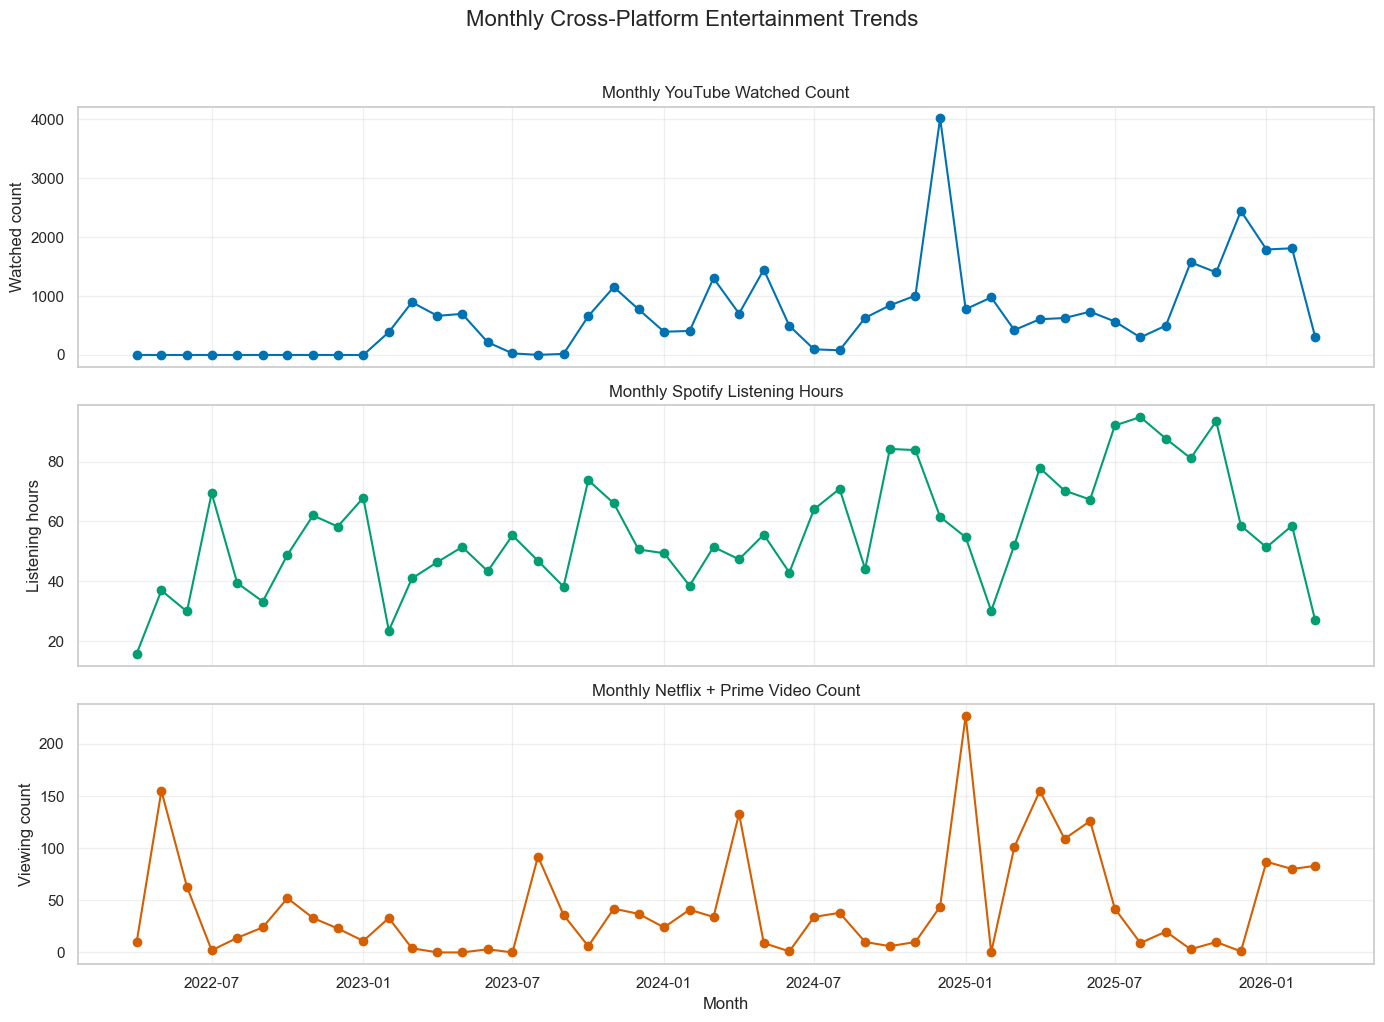

In [97]:
# Monthly cross-platform trends in separate panels because the units are different.
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(combined_monthly["month"], combined_monthly["youtube_daily_watched_count"], color="#0072B2", marker="o")
axes[0].set_title("Monthly YouTube Watched Count")
axes[0].set_ylabel("Watched count")

axes[1].plot(combined_monthly["month"], combined_monthly["spotify_daily_hours"], color="#009E73", marker="o")
axes[1].set_title("Monthly Spotify Listening Hours")
axes[1].set_ylabel("Listening hours")

axes[2].plot(combined_monthly["month"], combined_monthly["netflix_prime_daily_count"], color="#D55E00", marker="o")
axes[2].set_title("Monthly Netflix + Prime Video Count")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Viewing count")

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle("Monthly Cross-Platform Entertainment Trends", fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig(combined_image_dir / "combined_monthly_cross_platform_trends.png", dpi=300)
plt.show()

**Distribution Plots**

These plots inspect skew and outliers before any later statistical testing.

`youtube_daily_watched_count` is the number of YouTube watch records on a day. `spotify_daily_hours` is total Spotify listening time in hours. `netflix_prime_daily_count` is Netflix viewing records plus Prime Video watch records. `daily_distinct_entertainment_platform_count` is how many of the four platforms were active that day.


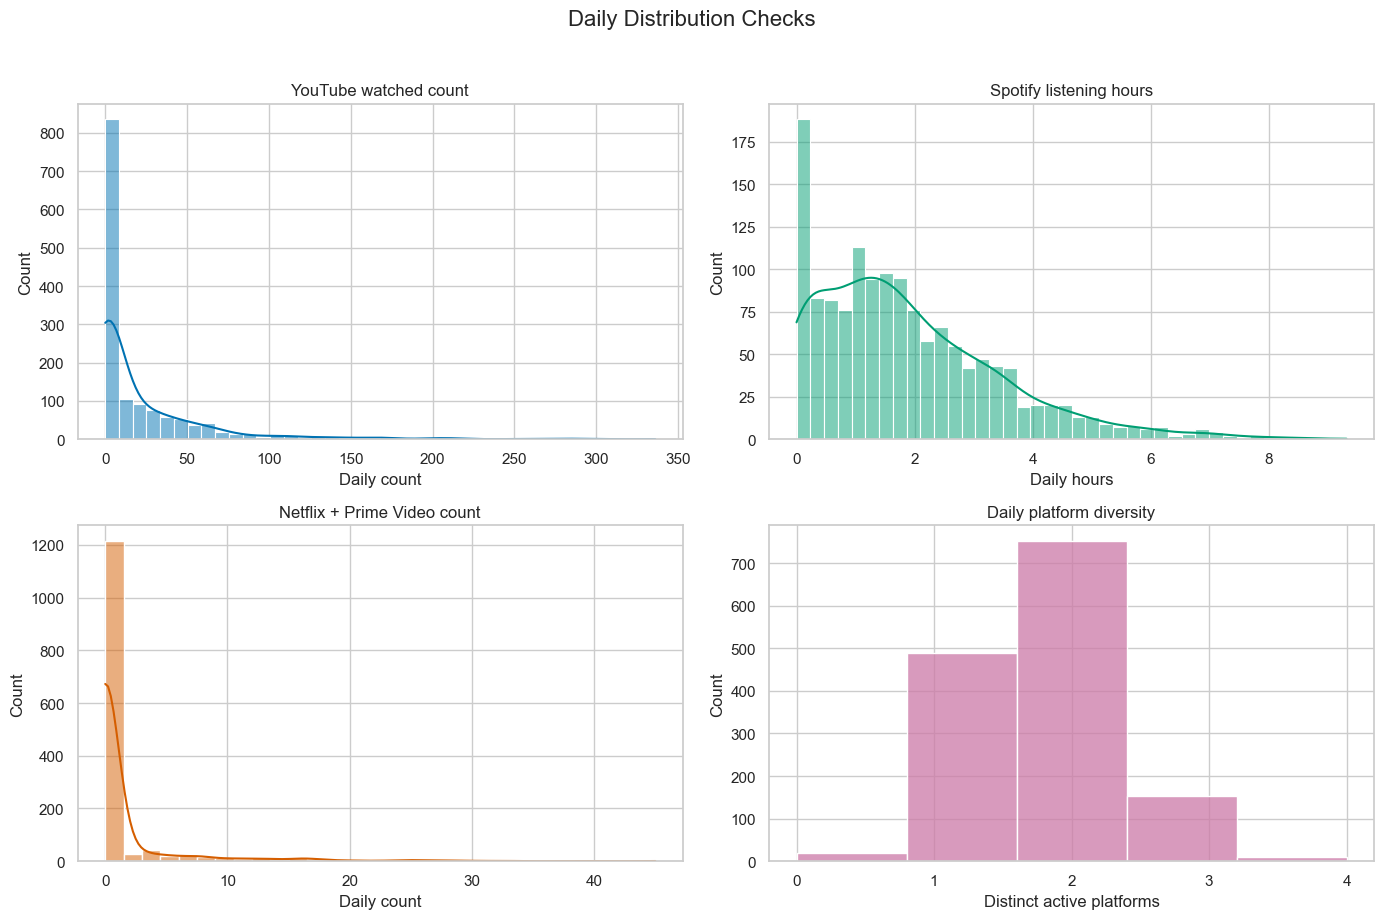

In [98]:
# Distribution overview for the main daily variables.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

sns.histplot(data=combined_daily, x="youtube_daily_watched_count", bins=40, kde=True, ax=axes[0], color="#0072B2")
axes[0].set_title("YouTube watched count")
axes[0].set_xlabel("Daily count")

sns.histplot(data=combined_daily, x="spotify_daily_hours", bins=40, kde=True, ax=axes[1], color="#009E73")
axes[1].set_title("Spotify listening hours")
axes[1].set_xlabel("Daily hours")

sns.histplot(data=combined_daily, x="netflix_prime_daily_count", bins=30, kde=True, ax=axes[2], color="#D55E00")
axes[2].set_title("Netflix + Prime Video count")
axes[2].set_xlabel("Daily count")

sns.histplot(data=combined_daily, x="daily_distinct_entertainment_platform_count", bins=5, ax=axes[3], color="#CC79A7")
axes[3].set_title("Daily platform diversity")
axes[3].set_xlabel("Distinct active platforms")
axes[3].set_xticks([0, 1, 2, 3, 4])

fig.suptitle("Daily Distribution Checks", fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig(combined_image_dir / "combined_daily_distribution_overview.png", dpi=300)
plt.show()


**Academic Calendar Views**

These visuals compare activity across calendar labels. They are still EDA, not hypothesis tests.

`analysis_period` is the academic label joined from the calendar: ordinary term, final exam, outside calendar, or summer work period. Add/drop days are grouped into ordinary term because they are not central to this project question.

The box plots keep each activity metric in its own panel because the units are not the same.

For the average activity plot, I use a relative index instead of raw units. A value of `1.0` means that period equals the overall average for that same metric. Values above `1.0` mean higher than usual for that metric, and values below `1.0` mean lower than usual.


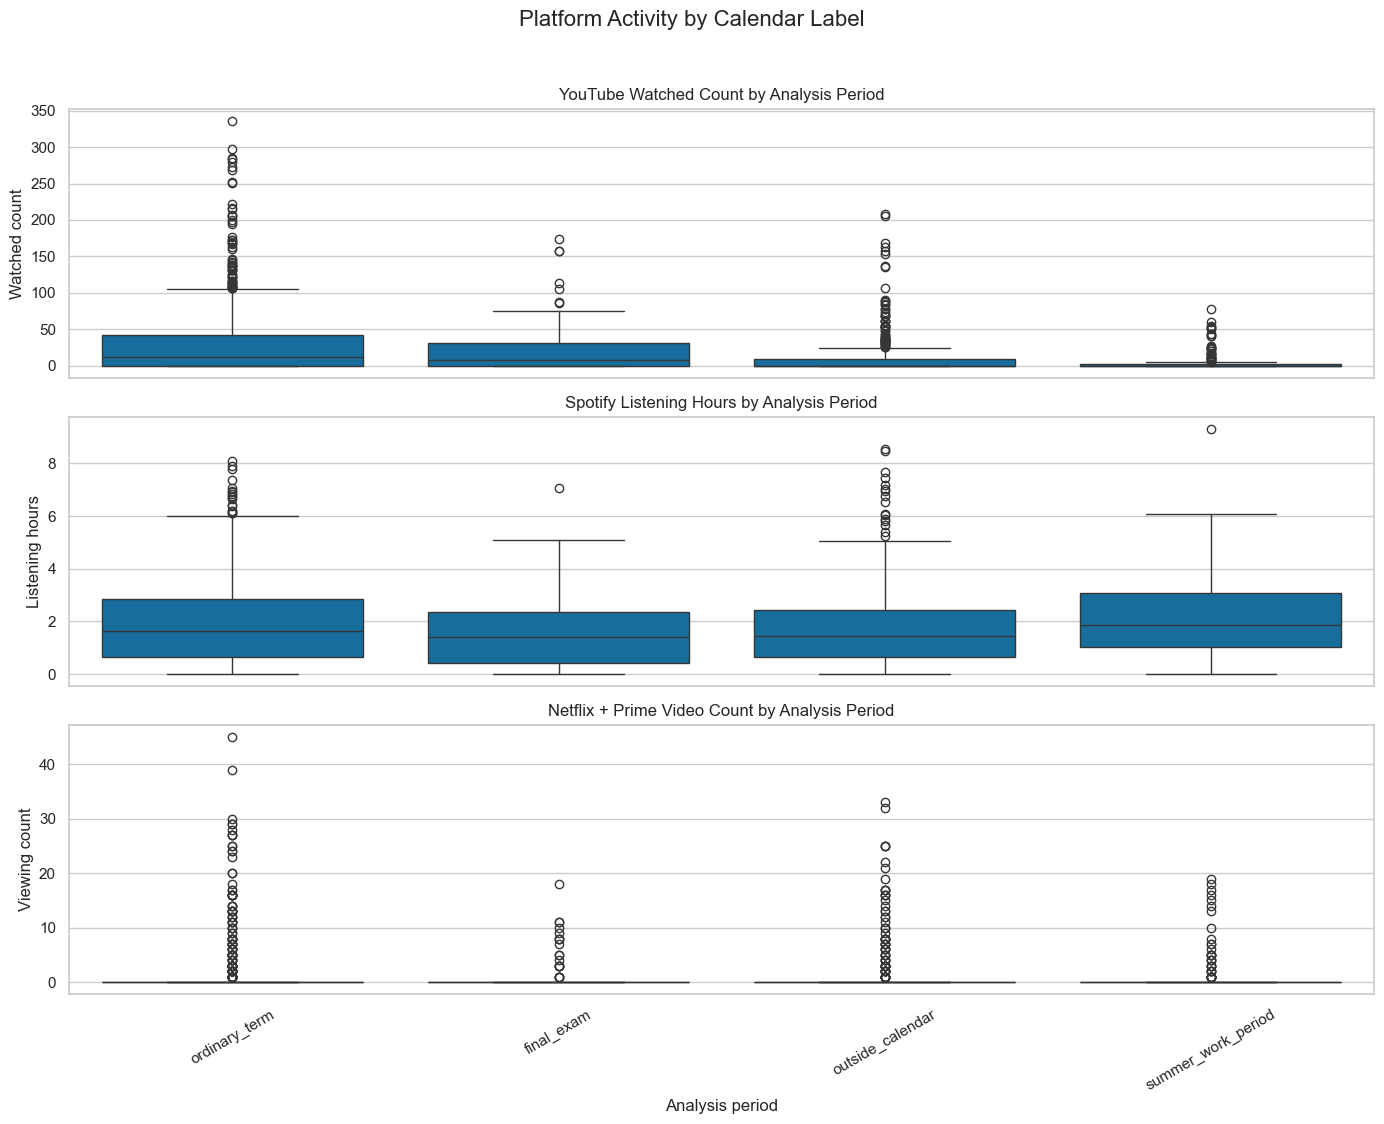

In [99]:
period_order = ["ordinary_term", "final_exam", "outside_calendar", "summer_work_period"]
existing_period_order = [period for period in period_order if period in combined_daily["analysis_period"].unique()]

# Box plots by analysis period for the main variables.
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

sns.boxplot(data=combined_daily, x="analysis_period", y="youtube_daily_watched_count", order=existing_period_order, ax=axes[0])
axes[0].set_title("YouTube Watched Count by Analysis Period")
axes[0].set_xlabel("")
axes[0].set_ylabel("Watched count")

sns.boxplot(data=combined_daily, x="analysis_period", y="spotify_daily_hours", order=existing_period_order, ax=axes[1])
axes[1].set_title("Spotify Listening Hours by Analysis Period")
axes[1].set_xlabel("")
axes[1].set_ylabel("Listening hours")

sns.boxplot(data=combined_daily, x="analysis_period", y="netflix_prime_daily_count", order=existing_period_order, ax=axes[2])
axes[2].set_title("Netflix + Prime Video Count by Analysis Period")
axes[2].set_xlabel("Analysis period")
axes[2].set_ylabel("Viewing count")
axes[2].tick_params(axis="x", rotation=30)

fig.suptitle("Platform Activity by Calendar Label", fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig(combined_image_dir / "combined_platform_activity_by_analysis_period_boxplots.png", dpi=300)
plt.show()


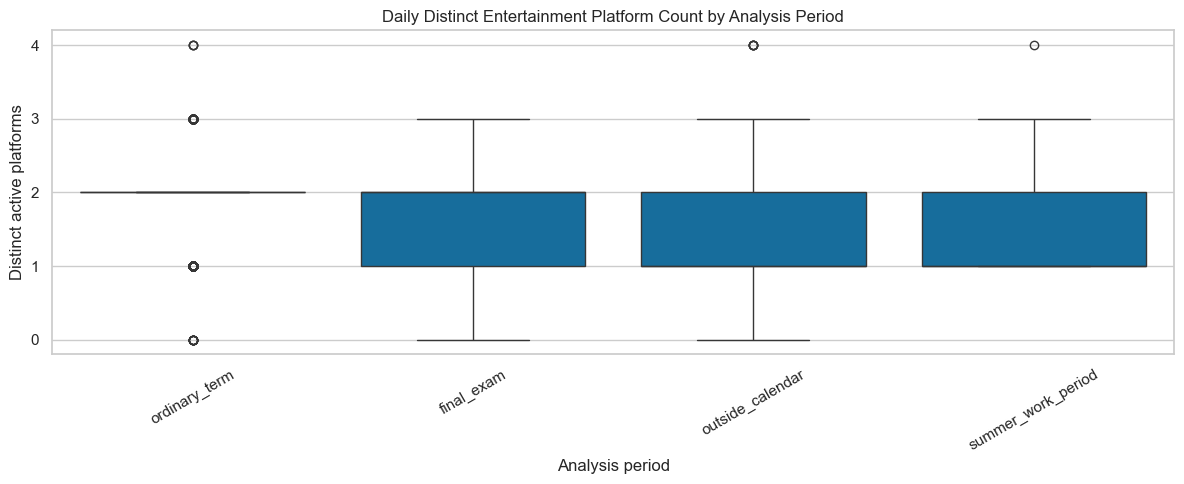

In [100]:
# Platform diversity by analysis period.
fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=combined_daily,
    x="analysis_period",
    y="daily_distinct_entertainment_platform_count",
    order=existing_period_order,
    ax=ax
)

ax.set_title("Daily Distinct Entertainment Platform Count by Analysis Period")
ax.set_xlabel("Analysis period")
ax.set_ylabel("Distinct active platforms")
ax.set_yticks([0, 1, 2, 3, 4])
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(combined_image_dir / "combined_platform_diversity_by_analysis_period.png", dpi=300)
plt.show()

In [101]:
# Mean activity by analysis period.
period_means = (
    combined_daily
    .groupby("analysis_period")[[
        "youtube_daily_watched_count",
        "spotify_daily_hours",
        "netflix_prime_daily_count",
        "daily_distinct_entertainment_platform_count"
    ]]
    .mean()
    .reindex(existing_period_order)
    .reset_index()
)

print("Mean activity by analysis period:")
print(period_means)

Mean activity by analysis period:
      analysis_period  youtube_daily_watched_count  spotify_daily_hours  \
0       ordinary_term                    30.763871             1.910594   
1          final_exam                    24.350515             1.645921   
2    outside_calendar                    13.261494             1.773925   
3  summer_work_period                     4.607843             2.118566   

   netflix_prime_daily_count  daily_distinct_entertainment_platform_count  
0                   1.458065                                     1.869677  
1                   1.237113                                     1.793814  
2                   1.770115                                     1.620690  
3                   1.034314                                     1.485294  


**Relative Average Plot**

This plot is for cross-platform comparison. It does not compare raw YouTube counts directly to Spotify hours. Instead, each metric is divided by its own overall average, so all bars use the same interpretation: `1.0` is normal for that metric, above `1.0` is higher than usual, and below `1.0` is lower than usual.


Relative average activity by analysis period:
       analysis_period                 metric  relative_average
0        ordinary_term        YouTube watched          1.379381
1           final_exam        YouTube watched          1.091821
2     outside_calendar        YouTube watched          0.594615
3   summer_work_period        YouTube watched          0.206605
4        ordinary_term          Spotify hours          1.011453
5           final_exam          Spotify hours          0.871337
6     outside_calendar          Spotify hours          0.939102
7   summer_work_period          Spotify hours          1.121552
8        ordinary_term  Netflix + Prime count          0.999655
9           final_exam  Netflix + Prime count          0.848170
10    outside_calendar  Netflix + Prime count          1.213598
11  summer_work_period  Netflix + Prime count          0.709130
12       ordinary_term     Platform diversity          1.069245
13          final_exam     Platform diversity          1.0

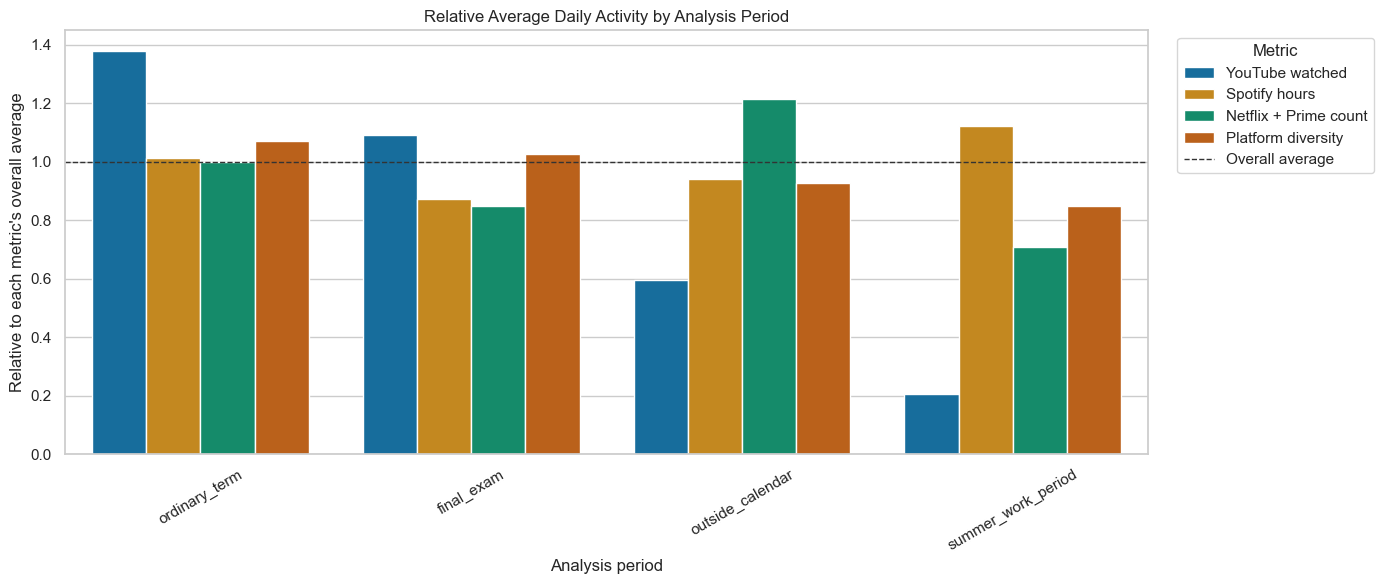

In [102]:
# Relative average activity by analysis period.
# The raw units are different, so this chart compares each metric against its own overall average.
relative_columns = [
    "youtube_daily_watched_count",
    "spotify_daily_hours",
    "netflix_prime_daily_count",
    "daily_distinct_entertainment_platform_count"
]

relative_labels = {
    "youtube_daily_watched_count": "YouTube watched",
    "spotify_daily_hours": "Spotify hours",
    "netflix_prime_daily_count": "Netflix + Prime count",
    "daily_distinct_entertainment_platform_count": "Platform diversity"
}

period_relative = period_means[["analysis_period"] + relative_columns].copy()

for column in relative_columns:
    overall_average = combined_daily[column].mean()
    if overall_average == 0:
        period_relative[column] = np.nan
    else:
        period_relative[column] = period_relative[column] / overall_average

period_relative_long = period_relative.melt(
    id_vars="analysis_period",
    value_vars=relative_columns,
    var_name="metric",
    value_name="relative_average"
)
period_relative_long["metric"] = period_relative_long["metric"].map(relative_labels)

print("Relative average activity by analysis period:")
print(period_relative_long)

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=period_relative_long,
    x="analysis_period",
    y="relative_average",
    hue="metric",
    order=existing_period_order,
    ax=ax
)

ax.axhline(1.0, color="#333333", linestyle="--", linewidth=1, label="Overall average")
ax.set_title("Relative Average Daily Activity by Analysis Period")
ax.set_xlabel("Analysis period")
ax.set_ylabel("Relative to each metric's overall average")
ax.tick_params(axis="x", rotation=30)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Metric")
plt.tight_layout()

plt.savefig(combined_image_dir / "combined_relative_activity_by_analysis_period.png", dpi=300)
plt.show()



**Relationship Plots**

These plots inspect possible same-day co-usage patterns that may guide later hypothesis testing.

Each dot is one day. The scatter plots show whether two daily variables tend to move together, but they do not prove causation. The colors show the academic period for that day.


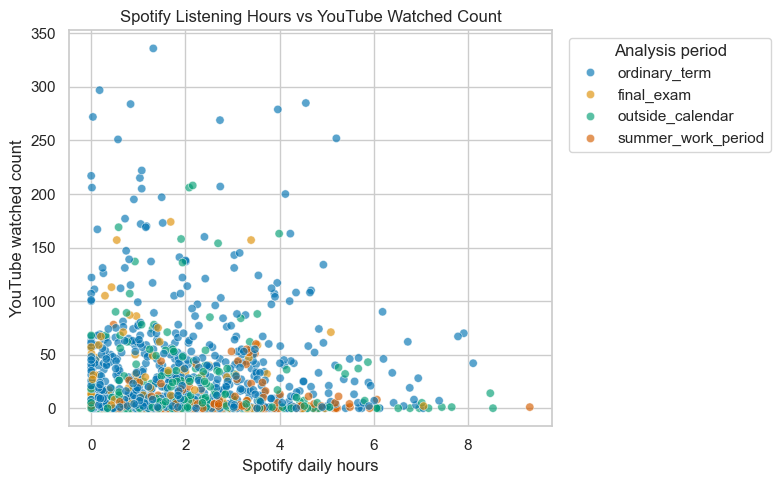

In [103]:
# Spotify hours vs YouTube watched count.
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=combined_daily,
    x="spotify_daily_hours",
    y="youtube_daily_watched_count",
    hue="analysis_period",
    hue_order=existing_period_order,
    alpha=0.65,
    ax=ax
)

ax.set_title("Spotify Listening Hours vs YouTube Watched Count")
ax.set_xlabel("Spotify daily hours")
ax.set_ylabel("YouTube watched count")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Analysis period")
plt.tight_layout()

plt.savefig(combined_image_dir / "combined_spotify_hours_vs_youtube_watched_scatter.png", dpi=300)
plt.show()

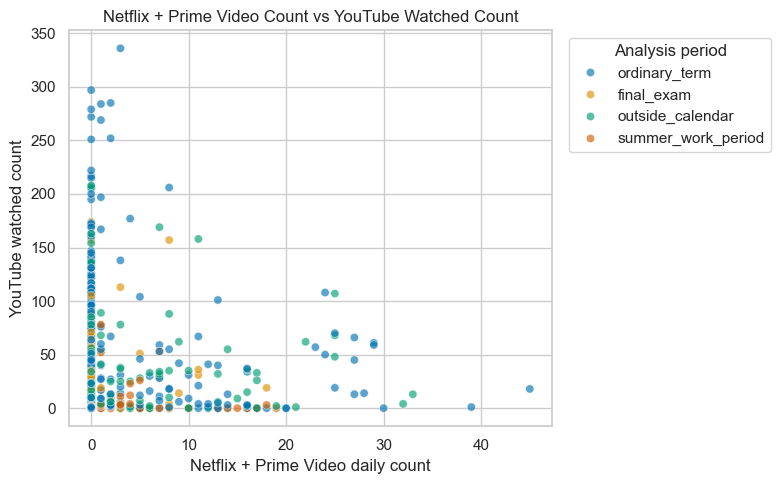

In [104]:
# Netflix + Prime Video vs YouTube watched count.
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=combined_daily,
    x="netflix_prime_daily_count",
    y="youtube_daily_watched_count",
    hue="analysis_period",
    hue_order=existing_period_order,
    alpha=0.65,
    ax=ax
)

ax.set_title("Netflix + Prime Video Count vs YouTube Watched Count")
ax.set_xlabel("Netflix + Prime Video daily count")
ax.set_ylabel("YouTube watched count")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Analysis period")
plt.tight_layout()

plt.savefig(combined_image_dir / "combined_netflix_prime_vs_youtube_watched_scatter.png", dpi=300)
plt.show()

**Correlation Heatmap Variables**

The heatmap uses Spearman correlation, which is useful here because daily activity is not normally distributed and has many low-count days.

Positive values mean two variables usually increase together. Negative values mean one variable is often higher when the other is lower. Values near zero mean there is not a clear same-day monotonic relationship in this EDA view.

Short plot labels are used to keep the heatmap readable. For example, `Netflix + Prime count` means Netflix viewing count plus Prime Video watch count for the same day.


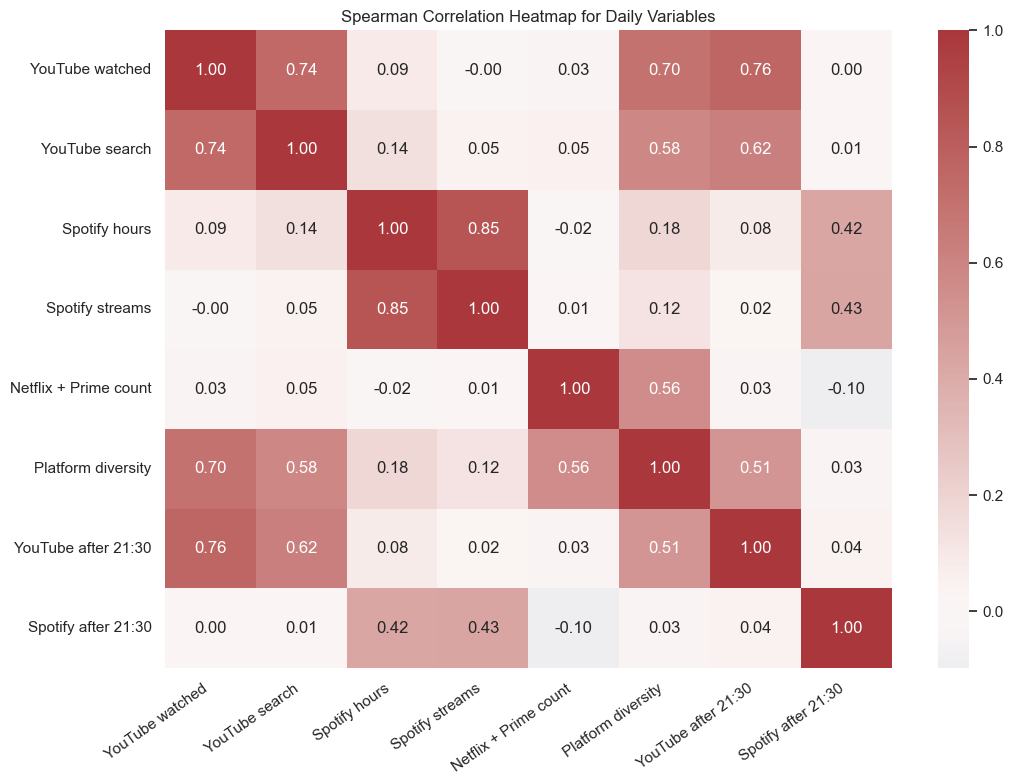

In [105]:
# Correlation heatmap for daily variables.
# The plot uses shorter labels so it is easier to read than the full column names.
correlation_columns = [
    "youtube_daily_watched_count",
    "youtube_daily_search_count",
    "spotify_daily_hours",
    "spotify_daily_stream_count",
    "netflix_prime_daily_count",
    "daily_distinct_entertainment_platform_count",
    "youtube_after_2130_count",
    "spotify_after_2130_hours"
]

correlation_labels = {
    "youtube_daily_watched_count": "YouTube watched",
    "youtube_daily_search_count": "YouTube search",
    "spotify_daily_hours": "Spotify hours",
    "spotify_daily_stream_count": "Spotify streams",
    "netflix_prime_daily_count": "Netflix + Prime count",
    "daily_distinct_entertainment_platform_count": "Platform diversity",
    "youtube_after_2130_count": "YouTube after 21:30",
    "spotify_after_2130_hours": "Spotify after 21:30"
}

combined_correlation = combined_daily[correlation_columns].corr(method="spearman")
combined_correlation = combined_correlation.rename(index=correlation_labels, columns=correlation_labels)

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    combined_correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=ax
)

ax.set_title("Spearman Correlation Heatmap for Daily Variables")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(combined_image_dir / "combined_daily_variable_correlation_heatmap.png", dpi=300)
plt.show()


**After-9:30 PM Views**

The after-9:30 PM window is defined as `21:30-04:59` in Istanbul time. Only YouTube and Spotify are used because they have exact timestamps.

`youtube_after_2130_count` is the number of YouTube records in that time window. `spotify_after_2130_hours` is the Spotify listening time in that time window.


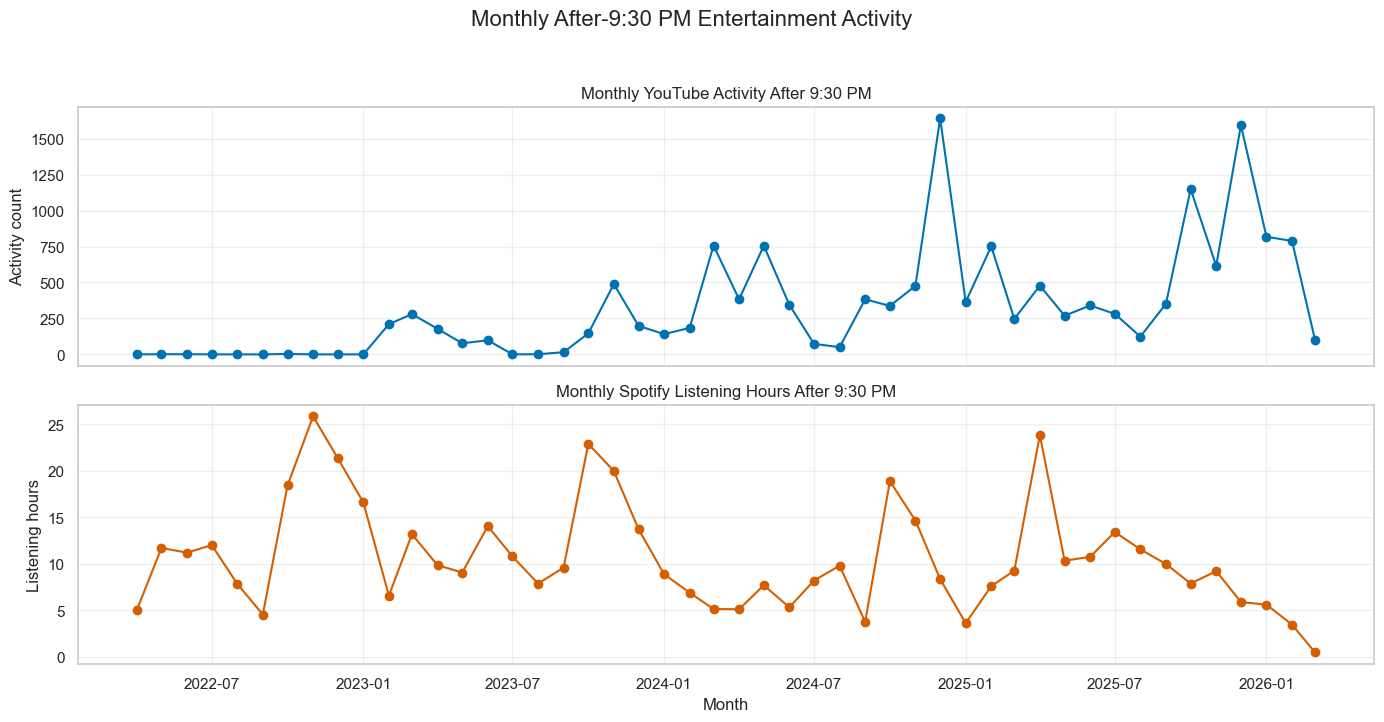

In [106]:
# Monthly after-9:30 PM activity in separate panels because units differ.
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(combined_monthly["month"], combined_monthly["youtube_after_2130_count"], color="#0072B2", marker="o")
axes[0].set_title("Monthly YouTube Activity After 9:30 PM")
axes[0].set_ylabel("Activity count")
axes[0].grid(alpha=0.3)

axes[1].plot(combined_monthly["month"], combined_monthly["spotify_after_2130_hours"], color="#D55E00", marker="o")
axes[1].set_title("Monthly Spotify Listening Hours After 9:30 PM")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Listening hours")
axes[1].grid(alpha=0.3)

fig.suptitle("Monthly After-9:30 PM Entertainment Activity", fontsize=16, y=1.03)
fig.tight_layout()

plt.savefig(combined_image_dir / "combined_monthly_after_2130_activity.png", dpi=300)
plt.show()

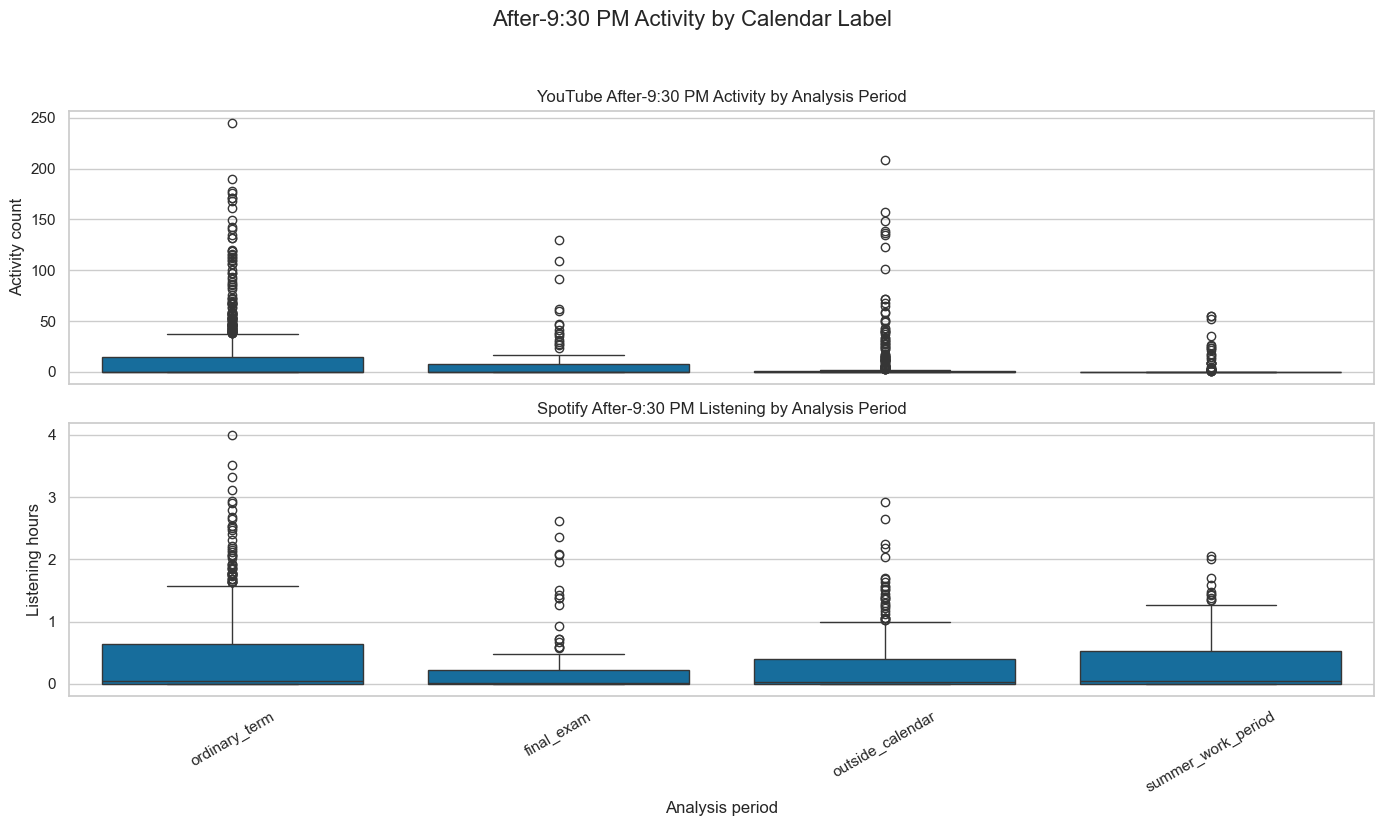

In [107]:
# After-9:30 PM activity by analysis period.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sns.boxplot(data=combined_daily, x="analysis_period", y="youtube_after_2130_count", order=existing_period_order, ax=axes[0])
axes[0].set_title("YouTube After-9:30 PM Activity by Analysis Period")
axes[0].set_xlabel("")
axes[0].set_ylabel("Activity count")

sns.boxplot(data=combined_daily, x="analysis_period", y="spotify_after_2130_hours", order=existing_period_order, ax=axes[1])
axes[1].set_title("Spotify After-9:30 PM Listening by Analysis Period")
axes[1].set_xlabel("Analysis period")
axes[1].set_ylabel("Listening hours")
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle("After-9:30 PM Activity by Calendar Label", fontsize=16, y=1.03)
fig.tight_layout()

plt.savefig(combined_image_dir / "combined_after_2130_by_analysis_period_boxplots.png", dpi=300)
plt.show()

**Overview Panel**

This final panel gives a compact visual summary similar to the multi-plot examples from the course recitations. It combines trend, distribution, and relationship views without running any formal test.


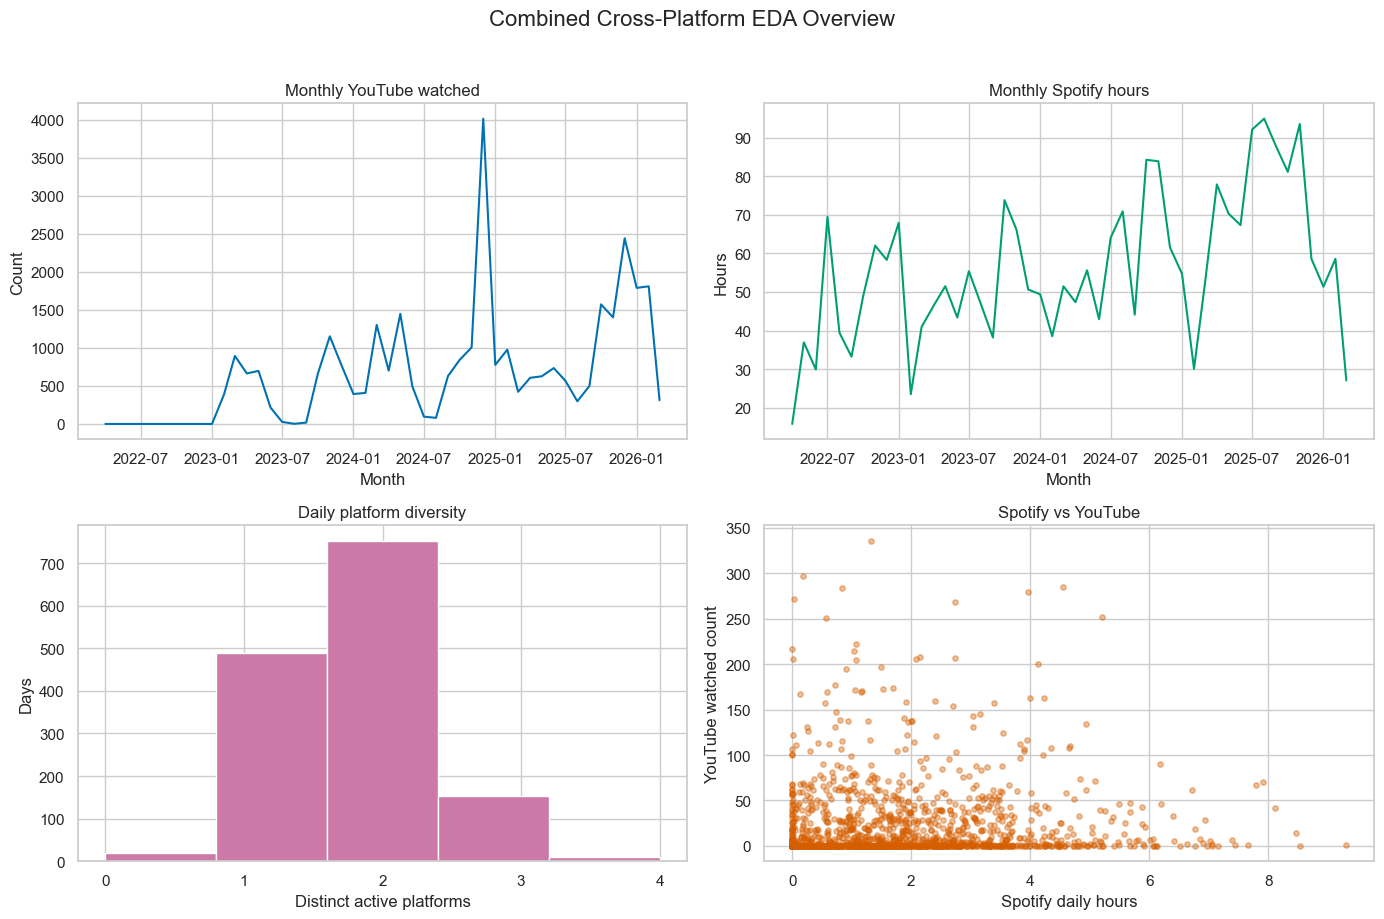

In [108]:
# 2x2 overview plot.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

axes[0].plot(combined_monthly["month"], combined_monthly["youtube_daily_watched_count"], color="#0072B2")
axes[0].set_title("Monthly YouTube watched")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Count")

axes[1].plot(combined_monthly["month"], combined_monthly["spotify_daily_hours"], color="#009E73")
axes[1].set_title("Monthly Spotify hours")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Hours")

axes[2].hist(combined_daily["daily_distinct_entertainment_platform_count"], bins=5, color="#CC79A7", edgecolor="white")
axes[2].set_title("Daily platform diversity")
axes[2].set_xlabel("Distinct active platforms")
axes[2].set_ylabel("Days")
axes[2].set_xticks([0, 1, 2, 3, 4])

axes[3].scatter(
    combined_daily["spotify_daily_hours"],
    combined_daily["youtube_daily_watched_count"],
    alpha=0.4,
    s=15,
    color="#D55E00"
)
axes[3].set_title("Spotify vs YouTube")
axes[3].set_xlabel("Spotify daily hours")
axes[3].set_ylabel("YouTube watched count")

fig.suptitle("Combined Cross-Platform EDA Overview", fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig(combined_image_dir / "combined_eda_overview_panel.png", dpi=300)
plt.show()

**Final Notes**

The combined daily panel is ready for later hypothesis testing, but this notebook intentionally stops at EDA. The most important variables prepared here are `youtube_daily_watched_count`, `youtube_daily_search_count`, `spotify_daily_hours`, `spotify_daily_stream_count`, `netflix_prime_daily_count`, `daily_distinct_entertainment_platform_count`, `youtube_after_2130_count`, and `spotify_after_2130_hours`.

Summer calendar days are labeled as `summer_work_period` to avoid treating those dates as summer-school academic pressure.
